# S3M kNN vs GMM — same epoch, same field (apples-to-apples)

Controlled comparison: **same 21K objects**, **same May 9 2026 NEOCP field**,
scored with both the old S3M kNN map and the new GMM map.

- **Objects**: `s3m_digest2_comparison_2026-05-09T22_neocp.parquet` — 21,027 objects in the May 9 NEOCP antisun patch (center lon=229°, ±30°)
- **S3M scores**: already in the parquet (`P_NEO_vdp`, `P_NEO_d2`)
- **GMM scores**: re-computed here by interpolating `prob_maps_gmm/prob_maps_2026-05-01_antisun.npz` at each object's `(vlam, vbeta, mag_bin)`

Figures 1–3: map structure comparison (same as `sorcha_gmm_s3m_comparison.ipynb`).  
Figure 4: apples-to-apples ROC — S3M VDP vs GMM VDP vs digest2, **all on the same 21K objects**.


In [1]:
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

sys.path.insert(0, "src")
import velocity_density_pipeline as vdp

mpl.rcParams.update({
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "figure.dpi": 150,
})

In [2]:
S3M_MAP_PATH = "prob_maps/prob_maps_2026-05-09T22_neocp.npz"
GMM_MAP_PATH = "prob_maps_gmm/prob_maps_2026-05-01_antisun.npz"
PARQUET      = "s3m_digest2_comparison_2026-05-09T22_neocp.parquet"

SHOW_BINS  = ["18_20", "mag22", "mag24+"]
BIN_LABELS = {"18_20": "18–20", "mag22": "22–23", "mag24+": "24+"}

In [3]:
# ── Load maps ─────────────────────────────────────────────────────────────────
# S3M map: nearest-dist mask ON (0.2 deg/day) — as originally used
s3m = vdp.ProbMapSet.from_npz(S3M_MAP_PATH)

# GMM map: mask OFF (inf) — as used in our Sorcha scoring
gmm = vdp.ProbMapSet.from_npz(GMM_MAP_PATH, mask_radius_deg_per_day=float('inf'))

print(f"S3M  center=({s3m.center_lon_deg:.1f}, {s3m.center_lat_deg:.1f})  "
      f"grid {s3m.x_grid[0]:.1f}..{s3m.x_grid[-1]:.1f}  ({len(s3m.x_grid)} pts)")
print(f"GMM  center=({gmm.center_lon_deg:.1f}, {gmm.center_lat_deg:.1f})  "
      f"grid {gmm.x_grid[0]:.1f}..{gmm.x_grid[-1]:.1f}  ({len(gmm.x_grid)} pts)")
print(f"Bins: {[mb['label'] for mb in s3m.mag_bins]}")
print(f"Pops: {s3m.population_names}")

S3M  center=(229.0, 0.0)  grid -0.8..0.8  (161 pts)
GMM  center=(220.3, 0.0)  grid -2.0..2.0  (401 pts)
Bins: ['14_16', '16_18', '18_20', 'mag20', 'mag21', 'mag22', 'mag23', 'mag24+']
Pops: ['MBA', 'NEO', 'TNO', 'Trojans']


In [4]:
# ── Shared plotting helpers ───────────────────────────────────────────────────

def _log_density(density_2d):
    """Log10 density with 5-decade dynamic range, masked where density=0."""
    d = np.asarray(density_2d, dtype=float)
    pos = np.isfinite(d) & (d > 0)
    out = np.ma.masked_all(d.shape, dtype=float)
    if pos.any():
        out[pos] = np.log10(d[pos])
        vmax = float(np.nanmax(out))
        vmin = vmax - 5.0
    else:
        vmin, vmax = 0.0, 1.0
    return out, vmin, vmax


_DCMAP = mpl.colormaps["viridis"].copy()
_DCMAP.set_bad("0.88")


def _show_map(ax, data_2d, xg, yg, vmin, vmax, cmap, xlim, ylim, mode="density"):
    """imshow a density/probability map.

    data_2d is indexed as data[i_y, i_x] (vbeta along rows, vlam along cols),
    matching the meshgrid(x_grid, y_grid, indexing='xy') convention in VDP.
    No transpose needed — origin='lower' + extent does the right thing.
    """
    if mode == "density":
        img = np.ma.masked_invalid(data_2d)
    else:
        img = np.asarray(data_2d, dtype=float)

    extent = [xg[0], xg[-1], yg[0], yg[-1]]
    ax.imshow(img, origin="lower", extent=extent, aspect="equal",
              vmin=vmin, vmax=vmax, cmap=cmap, interpolation="bilinear")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.axhline(0, lw=0.5, color="white", ls="--", alpha=0.5)
    ax.axvline(0, lw=0.5, color="white", ls="--", alpha=0.5)


def _label_ax(ax, xlabel=True, ylabel=True):
    if xlabel:
        ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    if ylabel:
        ax.set_ylabel(r"$v_\beta$ (deg/day)")


def _add_colorbar(fig, axes_row, vrange, label, cmap):
    norm = mpl.colors.Normalize(*vrange)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=axes_row, shrink=0.85, pad=0.02)
    cb.set_label(label, fontsize=9)
    return cb

## Figure 1 — Log density: S3M kNN vs GMM (±0.8 deg/day cut)

6 rows (MBA ×3 bins, NEO ×3 bins) × 2 columns (S3M | GMM).  
Shared color scale per row so you can directly compare density levels.
Both panels clipped to ±0.8 for a fair comparison on the same square.

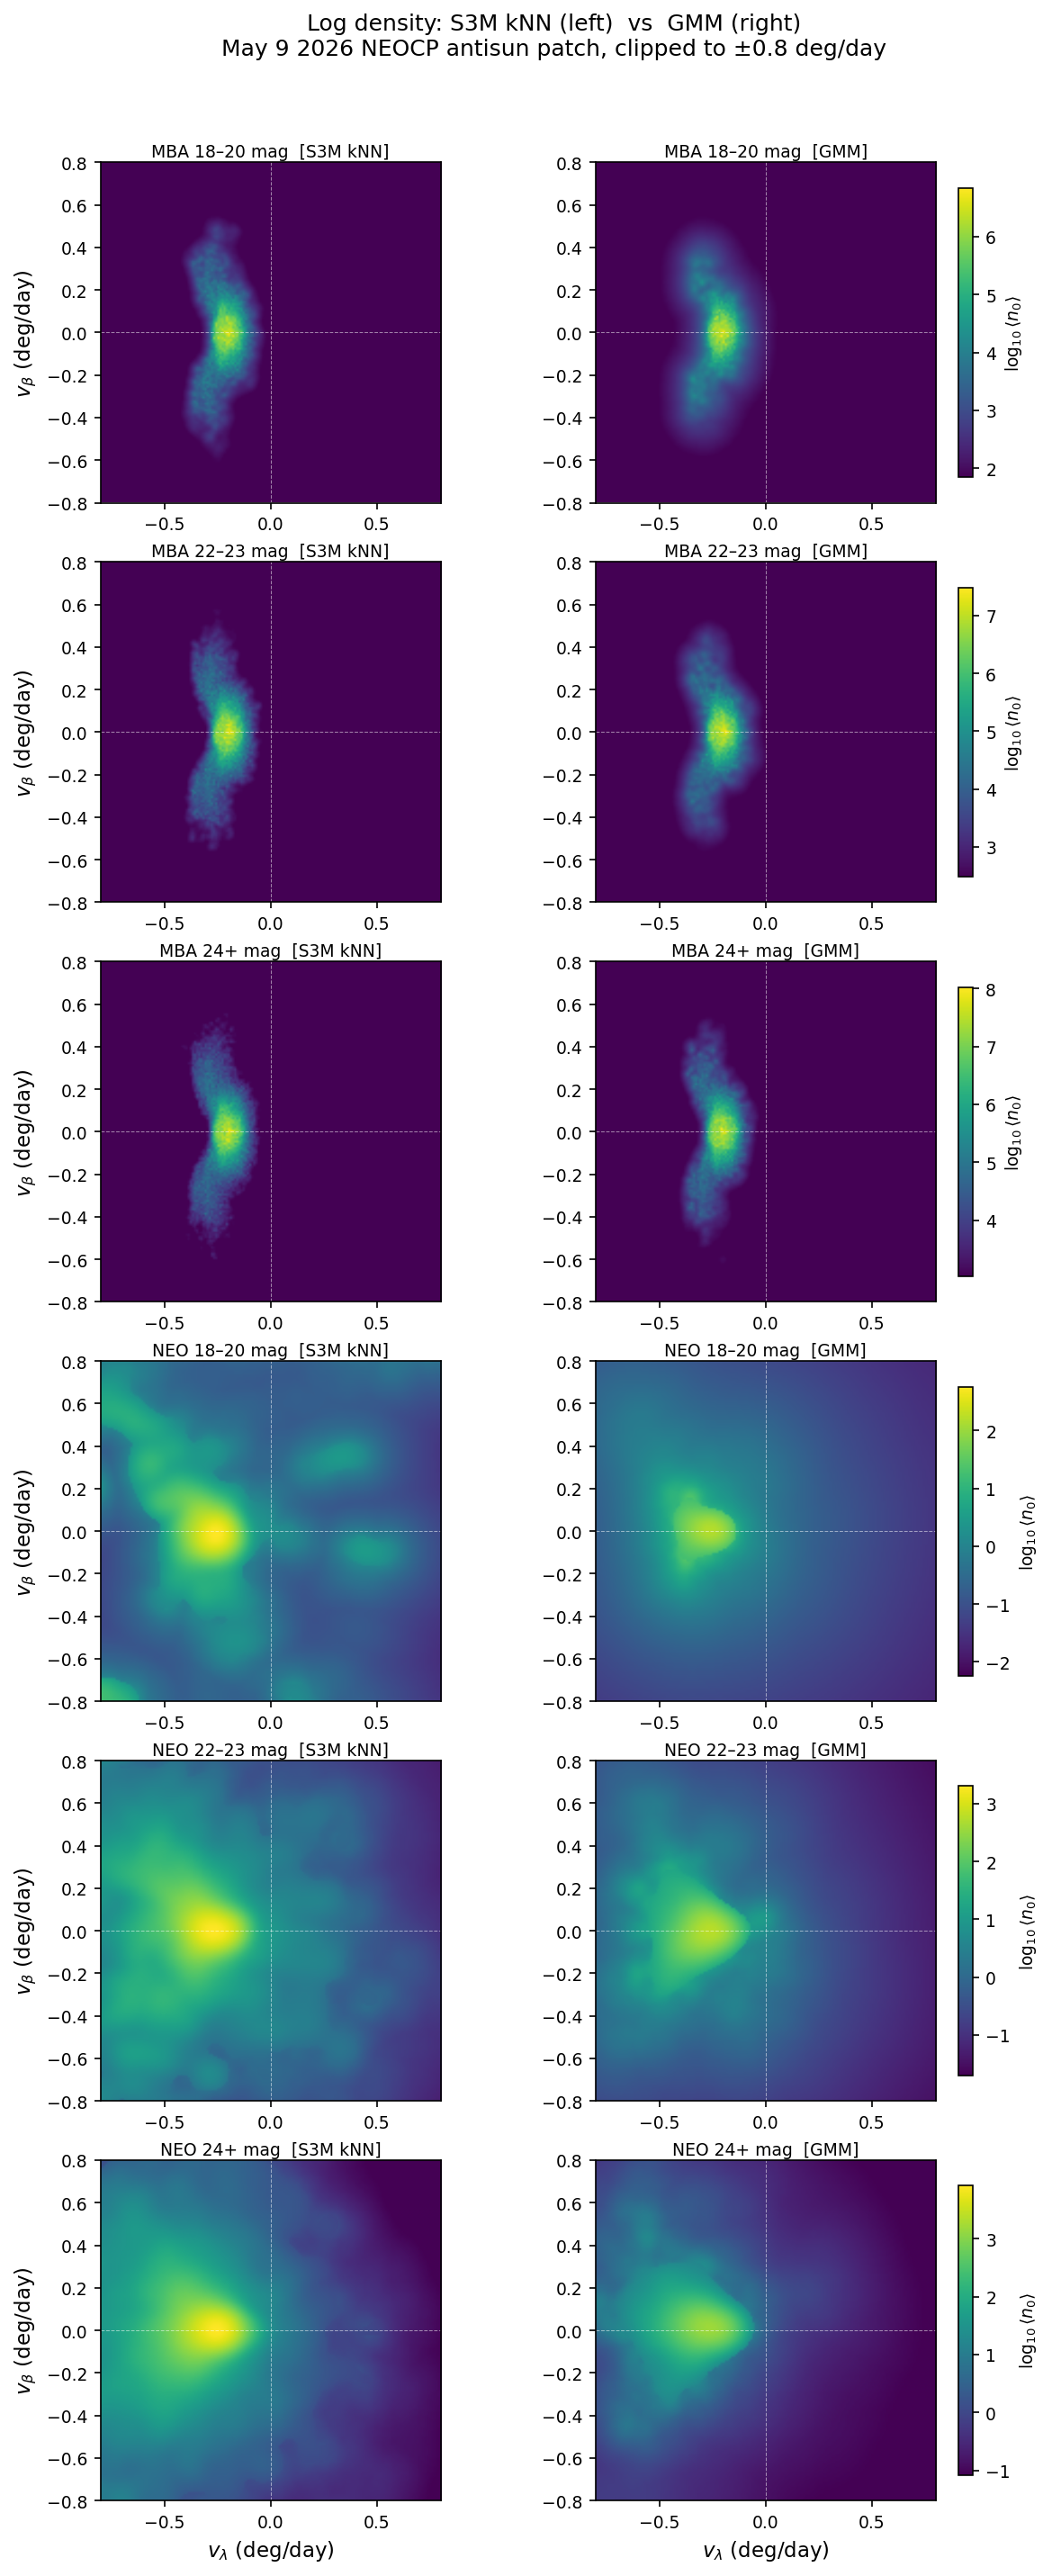

Saved.


In [5]:
VLIM_08 = (-0.8, 0.8)

pops_rows = [("MBA", b) for b in SHOW_BINS] + [("NEO", b) for b in SHOW_BINS]
n_rows = len(pops_rows)

fig1, axes1 = plt.subplots(n_rows, 2, figsize=(9, 3.2 * n_rows))
fig1.suptitle(
    "Log density: S3M kNN (left)  vs  GMM (right)\n"
    "May 9 2026 NEOCP antisun patch, clipped to ±0.8 deg/day",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

for row_i, (pop, bin_lbl) in enumerate(pops_rows):
    ax_s, ax_g = axes1[row_i, 0], axes1[row_i, 1]

    d_s3m = s3m.results[bin_lbl]["density_maps_downweighted_raw"][pop]
    d_gmm = gmm.results[bin_lbl]["density_maps_downweighted_raw"][pop]
    log_s3m, vs_min, vs_max = _log_density(d_s3m)
    log_gmm, vg_min, vg_max = _log_density(d_gmm)

    vmax = max(vs_max, vg_max)
    vmin = vmax - 5.0

    for ax, log_d, pms, lbl in [
        (ax_s, log_s3m, s3m, "S3M kNN"),
        (ax_g, log_gmm, gmm, "GMM"),
    ]:
        _show_map(ax, log_d, pms.x_grid, pms.y_grid, vmin, vmax,
                  _DCMAP, VLIM_08, VLIM_08, mode="density")
        _label_ax(ax, xlabel=(row_i == n_rows - 1), ylabel=(ax is ax_s))
        ax.set_title(f"{pop} {BIN_LABELS[bin_lbl]} mag  [{lbl}]", fontsize=9, pad=3)

    _add_colorbar(fig1, [ax_s, ax_g], (vmin, vmax),
                  r"$\log_{10}\langle n_0 \rangle$", _DCMAP)

plt.savefig("comparison_density_0p8cut.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved.")

## Figure 2 — P(NEO) probability: S3M kNN vs GMM (±0.8 cut)

3 rows (NEO ×3 mag bins) × 2 columns.  
S3M loaded with mask ON (cells with nearest-clone-dist > 0.2 zeroed);  
GMM loaded with mask OFF (smooth density everywhere).

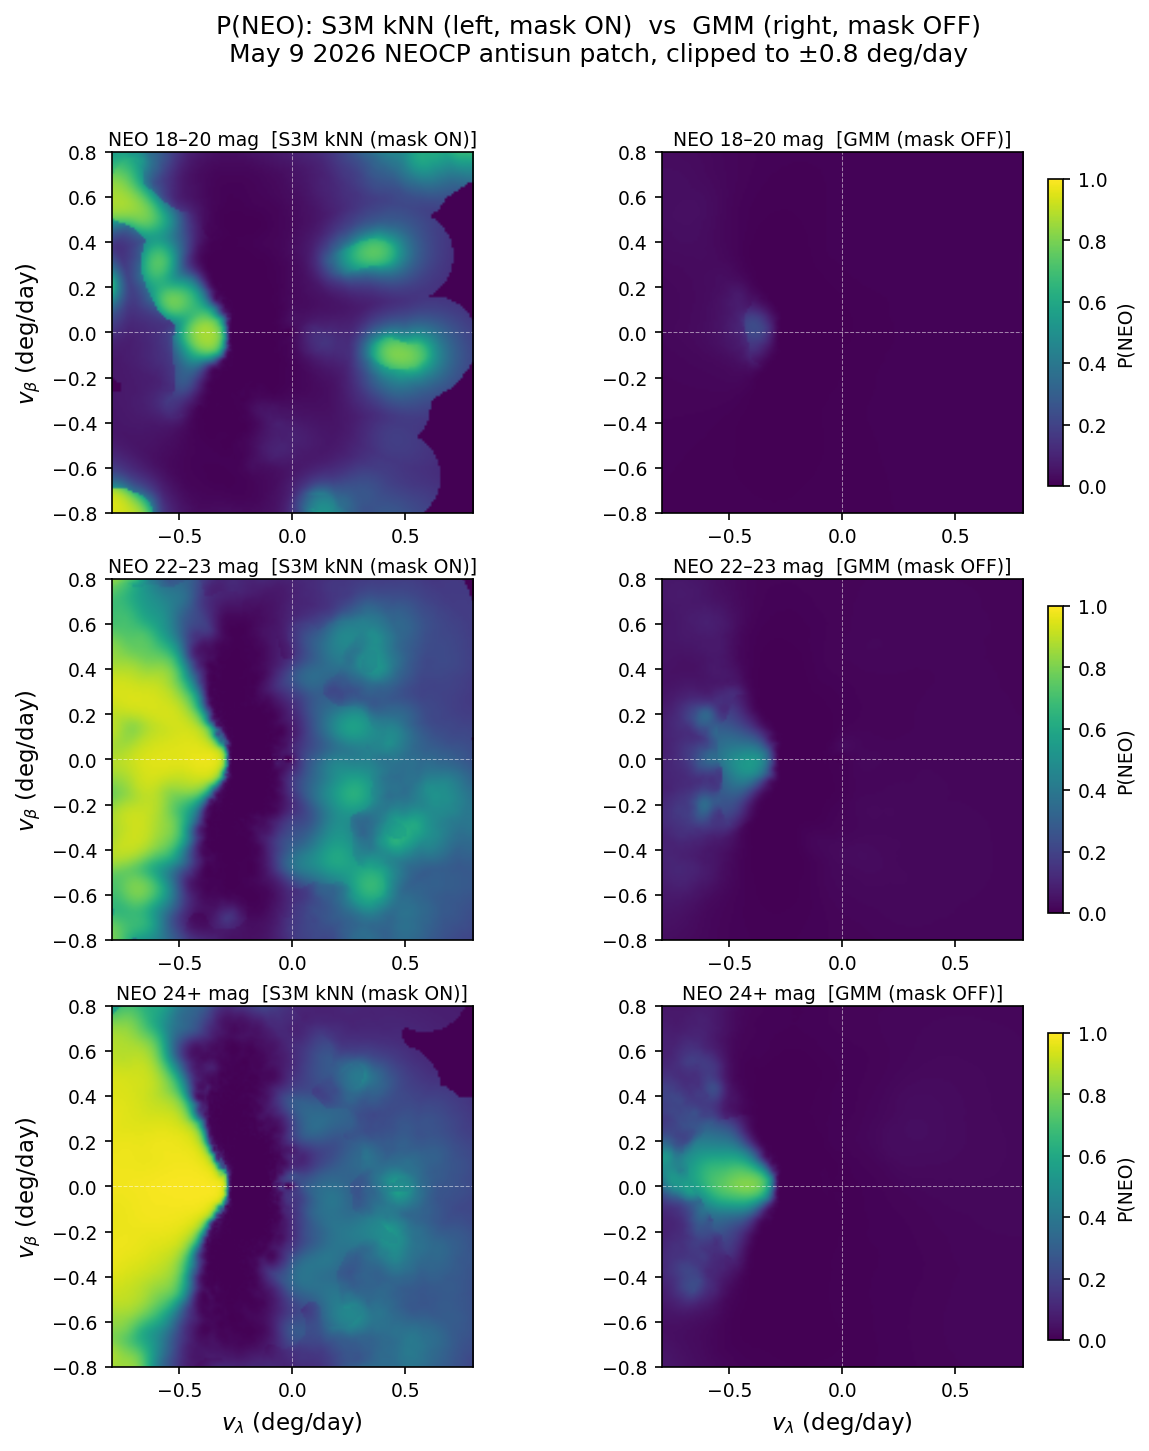

Saved.


In [6]:
fig2, axes2 = plt.subplots(len(SHOW_BINS), 2, figsize=(9, 3.2 * len(SHOW_BINS)))
fig2.suptitle(
    "P(NEO): S3M kNN (left, mask ON)  vs  GMM (right, mask OFF)\n"
    "May 9 2026 NEOCP antisun patch, clipped to ±0.8 deg/day",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])

for row_i, bin_lbl in enumerate(SHOW_BINS):
    ax_s, ax_g = axes2[row_i, 0], axes2[row_i, 1]

    p_s3m = s3m.get_probability_map(bin_lbl, "NEO")
    p_gmm = gmm.get_probability_map(bin_lbl, "NEO")

    for ax, prob, pms, lbl in [
        (ax_s, p_s3m, s3m, "S3M kNN (mask ON)"),
        (ax_g, p_gmm, gmm, "GMM (mask OFF)"),
    ]:
        _show_map(ax, prob, pms.x_grid, pms.y_grid, 0.0, 1.0,
                  "viridis", VLIM_08, VLIM_08, mode="probability")
        _label_ax(ax, xlabel=(row_i == len(SHOW_BINS) - 1), ylabel=(ax is ax_s))
        ax.set_title(f"NEO {BIN_LABELS[bin_lbl]} mag  [{lbl}]", fontsize=9, pad=3)

    _add_colorbar(fig2, [ax_s, ax_g], (0.0, 1.0), "P(NEO)", "viridis")

plt.savefig("comparison_probability_0p8cut.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved.")

## Figure 3 — GMM extended range ±2.0 deg/day

2 rows (density | probability) × 3 mag bins.  
The dashed white box marks the ±0.8 region shown in Figures 1–2.
The region from ±0.8 to ±2.0 is new coverage that rescues fast NEOs the S3M pipeline missed.

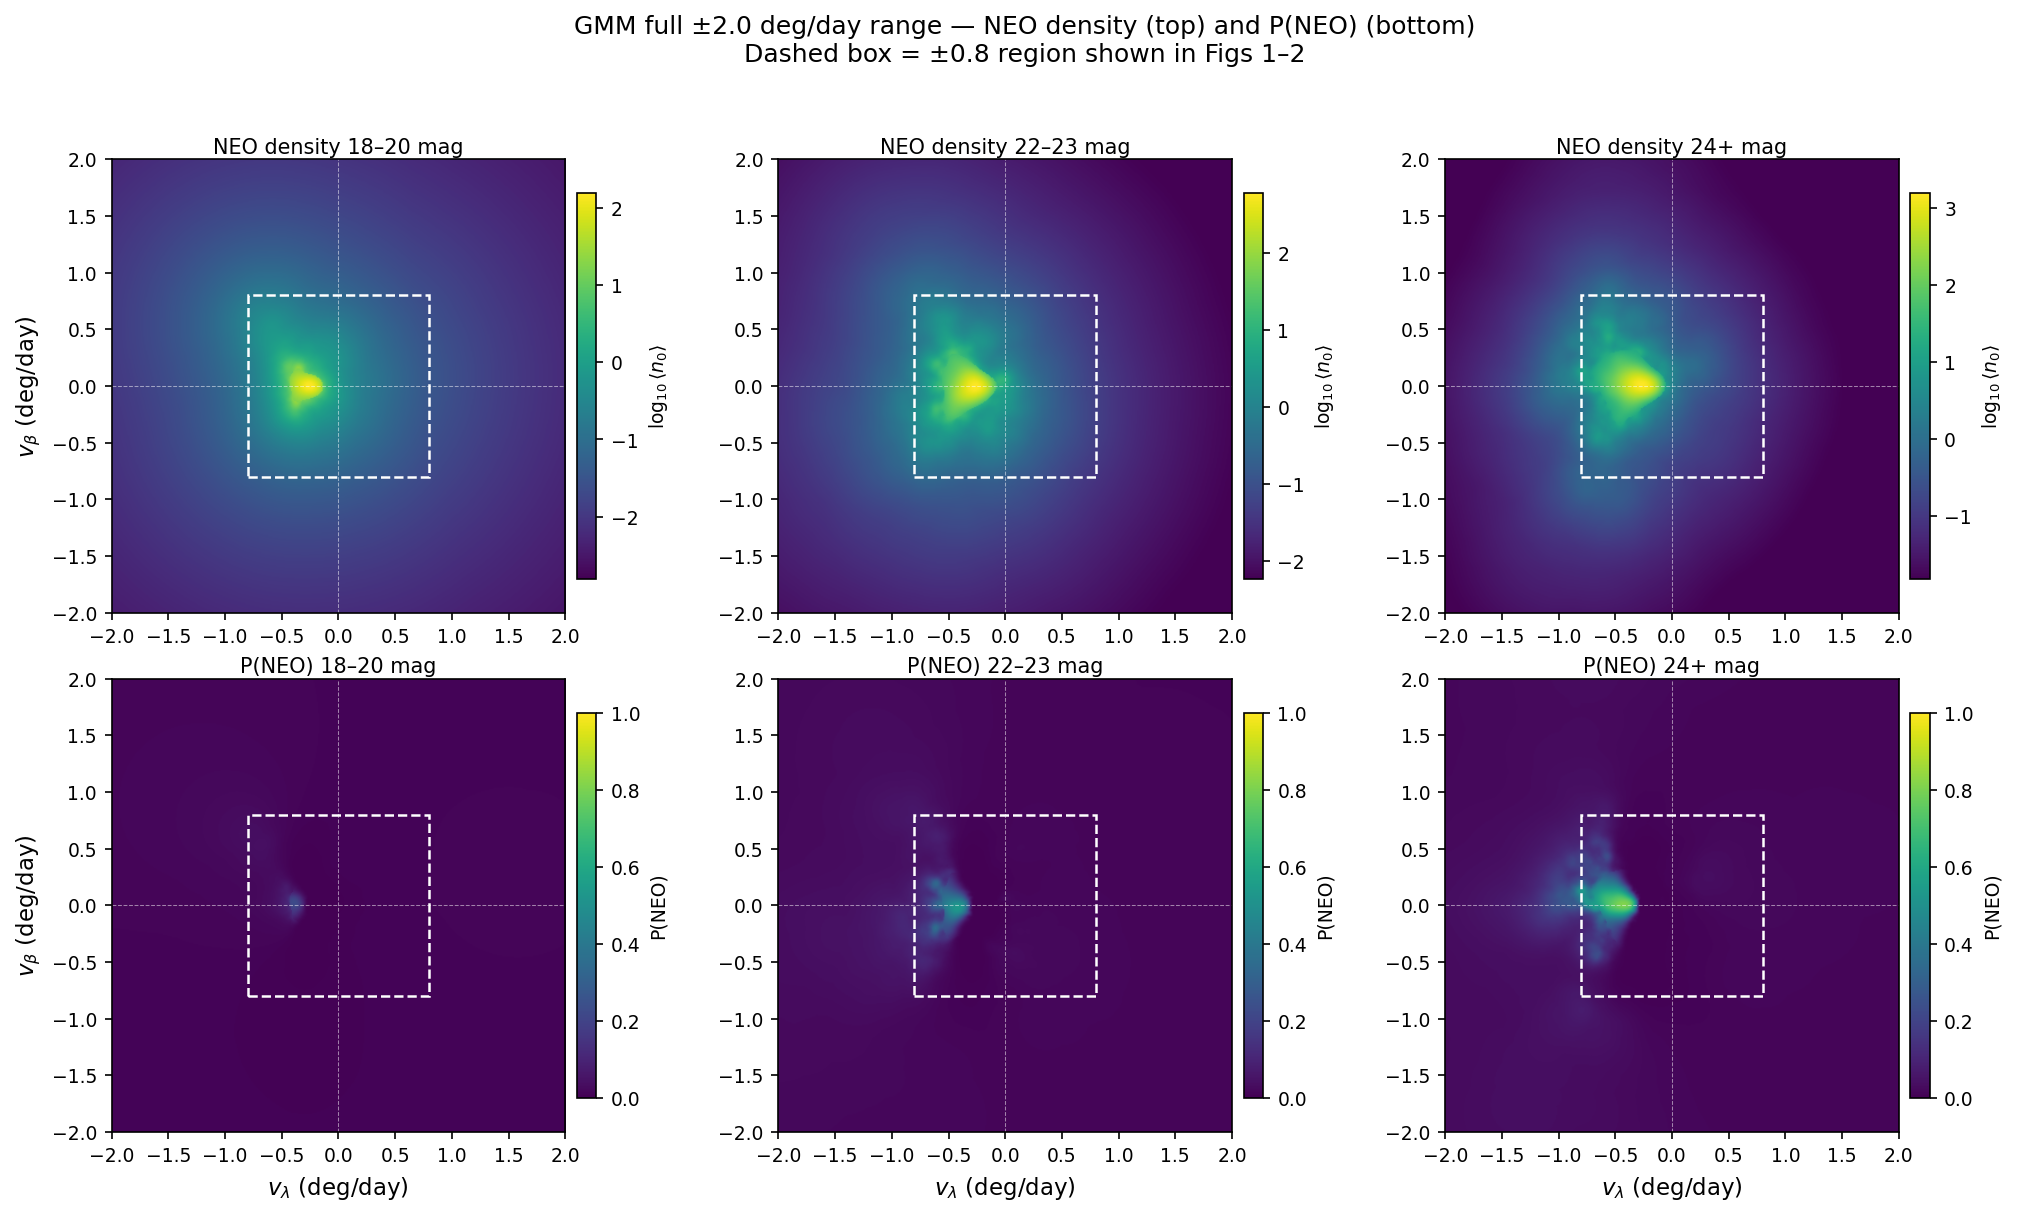

Saved.


In [7]:
VLIM_20 = (-2.0, 2.0)

fig3, axes3 = plt.subplots(2, len(SHOW_BINS), figsize=(4.5 * len(SHOW_BINS), 8))
fig3.suptitle(
    "GMM full ±2.0 deg/day range — NEO density (top) and P(NEO) (bottom)\n"
    "Dashed box = ±0.8 region shown in Figs 1–2",
    fontsize=12,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])

for col_i, bin_lbl in enumerate(SHOW_BINS):
    ax_d = axes3[0, col_i]
    d_gmm = gmm.results[bin_lbl]["density_maps_downweighted_raw"]["NEO"]
    log_d, vmin, vmax = _log_density(d_gmm)
    _show_map(ax_d, log_d, gmm.x_grid, gmm.y_grid, vmin, vmax,
              _DCMAP, VLIM_20, VLIM_20, mode="density")
    ax_d.set_title(f"NEO density {BIN_LABELS[bin_lbl]} mag", fontsize=10, pad=3)
    _label_ax(ax_d, xlabel=False, ylabel=(col_i == 0))
    _add_colorbar(fig3, [ax_d], (vmin, vmax), r"$\log_{10}\langle n_0 \rangle$", _DCMAP)

    ax_p = axes3[1, col_i]
    p_gmm = gmm.get_probability_map(bin_lbl, "NEO")
    _show_map(ax_p, p_gmm, gmm.x_grid, gmm.y_grid, 0.0, 1.0,
              "viridis", VLIM_20, VLIM_20, mode="probability")
    ax_p.set_title(f"P(NEO) {BIN_LABELS[bin_lbl]} mag", fontsize=10, pad=3)
    _label_ax(ax_p, xlabel=True, ylabel=(col_i == 0))
    _add_colorbar(fig3, [ax_p], (0.0, 1.0), "P(NEO)", "viridis")

    for ax in [ax_d, ax_p]:
        rect = plt.Rectangle((-0.8, -0.8), 1.6, 1.6,
                              linewidth=1.2, edgecolor="white",
                              linestyle="--", facecolor="none", zorder=5)
        ax.add_patch(rect)

plt.savefig("gmm_extended_range_2p0.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved.")

## Figure 4 — Apples-to-apples ROC: same 21K objects, both maps

Re-score the S3M objects with the GMM map by interpolating the GMM probability
map at each object's `(vlam, vbeta)` per mag bin. Then compare all three classifiers
on identical input data.


In [8]:
from scipy.interpolate import RegularGridInterpolator

df = pd.read_parquet(PARQUET)
print(f"Loaded {len(df):,} objects  |  NEOs: {(df.true_population=='NEO').sum():,}")
print(f"mag_app range: {df.mag_app.min():.1f} – {df.mag_app.max():.1f}")
print()

print("GMM mag bins:")
for mb in gmm.mag_bins:
    n = ((df.mag_app >= mb['mag_min']) & (df.mag_app < mb['mag_max'])).sum()
    print(f"  {mb['label']:10s}  [{mb['mag_min']:.0f}, {mb['mag_max']:.0f})  → {n:,} objects")

df = df.copy()
df["P_NEO_gmm"] = np.nan

for mb in gmm.mag_bins:
    mask = (df.mag_app >= mb['mag_min']) & (df.mag_app < mb['mag_max'])
    if not mask.any():
        continue
    p_map = gmm.get_probability_map(mb['label'], "NEO")
    interp = RegularGridInterpolator(
        (gmm.y_grid, gmm.x_grid), p_map,
        method="linear", bounds_error=False, fill_value=0.0,
    )
    pts = np.column_stack([df.loc[mask, "vbeta"].to_numpy(),
                           df.loc[mask, "vlam"].to_numpy()])
    df.loc[mask, "P_NEO_gmm"] = interp(pts)

print(f"\nGMM re-scored: {df['P_NEO_gmm'].notna().sum():,} / {len(df):,} objects")
print(f"P_NEO_gmm range: {df.P_NEO_gmm.min():.4f} – {df.P_NEO_gmm.max():.4f}")
print(f"P_NEO_vdp range: {df.P_NEO_vdp.min():.4f} – {df.P_NEO_vdp.max():.4f}")

Loaded 21,027 objects  |  NEOs: 1,119
mag_app range: 14.9 – 25.0

GMM mag bins:
  14_16       [14, 16)  → 7 objects
  16_18       [16, 18)  → 63 objects
  18_20       [18, 20)  → 361 objects
  mag20       [20, 21)  → 558 objects
  mag21       [21, 22)  → 1,276 objects
  mag22       [22, 23)  → 2,950 objects
  mag23       [23, 24)  → 6,274 objects
  mag24+      [24, 25)  → 9,538 objects

GMM re-scored: 21,027 / 21,027 objects
P_NEO_gmm range: 0.0000 – 0.8101
P_NEO_vdp range: 0.0000 – 0.9918


In [9]:
is_neo = (df["true_population"] == "NEO").to_numpy()
N = is_neo.sum()

def sweep(scores, label):
    """Vectorized threshold sweep — no Python loop."""
    thresholds = np.linspace(0, 1, 501)
    s = np.asarray(scores)[:, None]        # (n_obj, 1)
    above = s > thresholds[None, :]        # (n_obj, 501)
    tp = above[is_neo].sum(axis=0).astype(float)
    fp = above[~is_neo].sum(axis=0).astype(float)
    comp = tp / max(N, 1)
    cont = fp / np.maximum(tp + fp, 1)
    pur  = 1 - cont
    f1   = np.where(pur + comp > 0, 2*pur*comp / (pur + comp + 1e-12), 0.0)
    i    = np.argmax(f1)
    print(f"{label:22s}  F1={f1[i]:.3f}  comp={comp[i]:.1%}  cont={cont[i]:.1%}")
    return comp, cont, (f1[i], comp[i], cont[i], thresholds[i])

print(f"Objects: {len(df):,}  |  NEOs: {N:,}\n")
s3m_comp, s3m_cont, s3m_best = sweep(df["P_NEO_vdp"].to_numpy(),  "VDP S3M kNN")
gmm_comp, gmm_cont, gmm_best = sweep(df["P_NEO_gmm"].to_numpy(),  "VDP GMM (same objs)")
d2_comp,  d2_cont,  d2_best  = sweep(df["P_NEO_d2"].to_numpy(),   "digest2")

Objects: 21,027  |  NEOs: 1,119

VDP S3M kNN             F1=0.847  comp=75.1%  cont=2.8%
VDP GMM (same objs)     F1=0.842  comp=76.9%  cont=7.0%
digest2                 F1=0.655  comp=52.2%  cont=12.2%


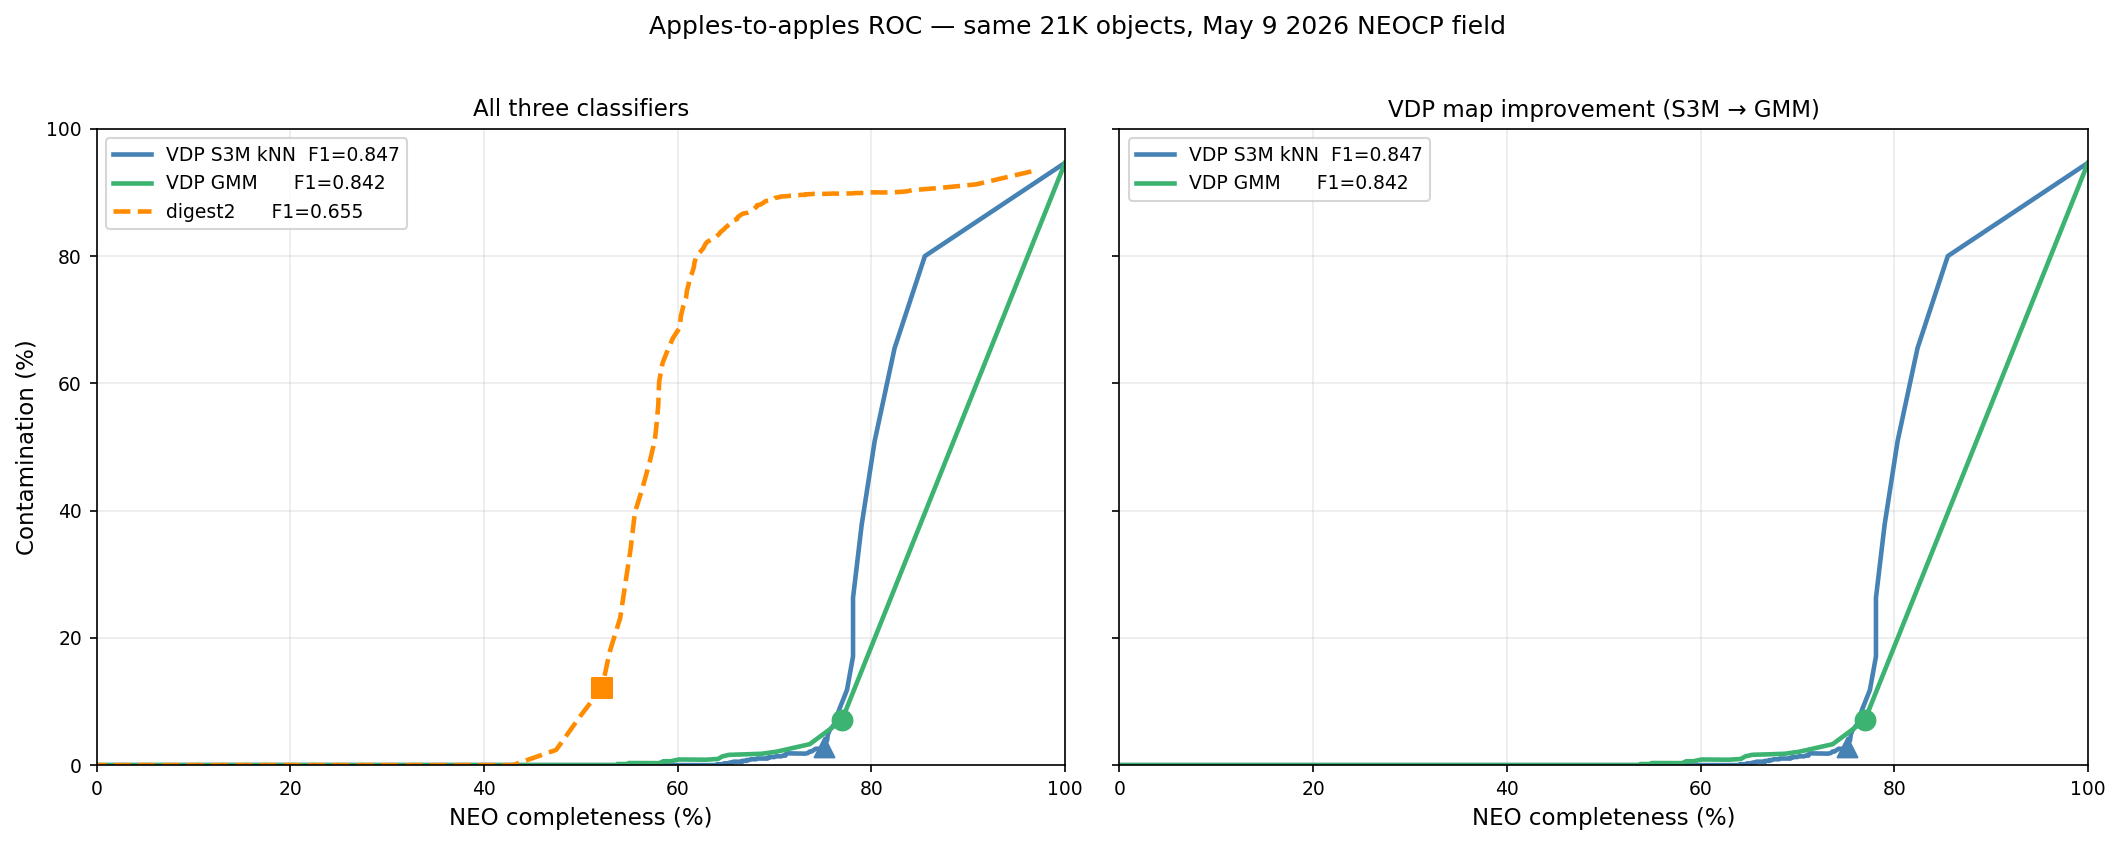

Saved: outputs/roc_singleepoch_apples.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.suptitle("Apples-to-apples ROC — same 21K objects, May 9 2026 NEOCP field", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])

# Left: all three curves overlaid
ax = axes[0]
ax.plot(s3m_comp*100, s3m_cont*100, lw=2.2, color="steelblue",
        label=f"VDP S3M kNN  F1={s3m_best[0]:.3f}")
ax.plot(gmm_comp*100, gmm_cont*100, lw=2.2, color="mediumseagreen",
        label=f"VDP GMM      F1={gmm_best[0]:.3f}")
ax.plot(d2_comp*100,  d2_cont*100,  lw=2.2, color="darkorange", ls="--",
        label=f"digest2      F1={d2_best[0]:.3f}")
for comp, cont, best, col, marker in [
    (s3m_comp, s3m_cont, s3m_best, "steelblue",    "^"),
    (gmm_comp, gmm_cont, gmm_best, "mediumseagreen","o"),
    (d2_comp,  d2_cont,  d2_best,  "darkorange",   "s"),
]:
    ax.scatter(best[1]*100, best[2]*100, s=90, color=col, marker=marker, zorder=5)
ax.set_xlabel("NEO completeness (%)"); ax.set_ylabel("Contamination (%)")
ax.set_title("All three classifiers"); ax.legend(fontsize=9); ax.grid(alpha=0.25)
ax.set_xlim(0, 100); ax.set_ylim(0, 100)

# Right: S3M vs GMM only (cleaner view of the map improvement)
ax2 = axes[1]
ax2.plot(s3m_comp*100, s3m_cont*100, lw=2.2, color="steelblue",
         label=f"VDP S3M kNN  F1={s3m_best[0]:.3f}")
ax2.plot(gmm_comp*100, gmm_cont*100, lw=2.2, color="mediumseagreen",
         label=f"VDP GMM      F1={gmm_best[0]:.3f}")
ax2.scatter(s3m_best[1]*100, s3m_best[2]*100, s=90, color="steelblue",    marker="^", zorder=5)
ax2.scatter(gmm_best[1]*100, gmm_best[2]*100, s=90, color="mediumseagreen",marker="o", zorder=5)
ax2.set_xlabel("NEO completeness (%)")
ax2.set_title("VDP map improvement (S3M → GMM)"); ax2.legend(fontsize=9); ax2.grid(alpha=0.25)
ax2.set_xlim(0, 100); ax2.set_ylim(0, 100)

plt.savefig("outputs/roc_singleepoch_apples.png", bbox_inches="tight", dpi=150)
plt.show(); plt.close(fig)
print("Saved: outputs/roc_singleepoch_apples.png")